# City comparison diagrams — deployment

Cross-city diagrams comparing Barcelona (the source / training city) with the five deployment cities
(Viladecans, Milan, Berlin, Lyon, Zaragoza):

1. **Noise distribution** — day dB distribution per city.
2. **Noise class share** — fraction of streets in each 0–4 noise class per city.
3. **Transfer — classification** — accuracy and within-±1-class of the Barcelona models on each city.
4. **Transfer — regression** — MAE (dB) and R² of the Barcelona models on each city.

Barcelona is the held-out 20% test set (source performance); every other city is the full-segment transfer
result of the original full-18-feature Barcelona models (`notebooks/_elena/models/`). Palette matches the
ablation study (`#d58430`, `#7251ce`, `#144849`).

## Libraries, palette, data

In [1]:
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error, r2_score

# ablation-study palette
MODEL_COLORS = ['#d58430', '#7251ce', '#144849']   # [LogReg/LinReg, XGBoost, Random Forest]
CITY_COLORS = {
    'Barcelona': '#144849', 'Viladecans': '#d58430', 'Milan': '#7251ce',
    'Berlin': '#c44e52', 'Lyon': '#4c72b0', 'Zaragoza': '#55a868',
}
CITIES = ['Barcelona', 'Viladecans', 'Milan', 'Berlin', 'Lyon', 'Zaragoza']
PREFIX = {'Viladecans': 'vil', 'Milan': 'mil', 'Berlin': 'ber', 'Lyon': 'lyo', 'Zaragoza': 'zgz'}
FIG = 'figures'
os.makedirs(FIG, exist_ok=True)

def paths(city):
    if city == 'Barcelona':
        base = '../../notebooks/_elena/data/bcn'
    else:
        base = f'../{city}/notebooks/data/{PREFIX[city]}'
    return base + '_noise_class_ml_dataset.csv', base + '_noise_regre_ml_dataset.csv'

class_df, regre_df = {}, {}
for c in CITIES:
    cp, rp = paths(c)
    class_df[c] = pd.read_csv(cp).dropna()
    regre_df[c] = pd.read_csv(rp).dropna()
print({c: len(class_df[c]) for c in CITIES})

{'Barcelona': 12854, 'Viladecans': 1613, 'Milan': 22164, 'Berlin': 70890, 'Lyon': 7159, 'Zaragoza': 14600}


## 1 — Noise distribution (day dB) per city

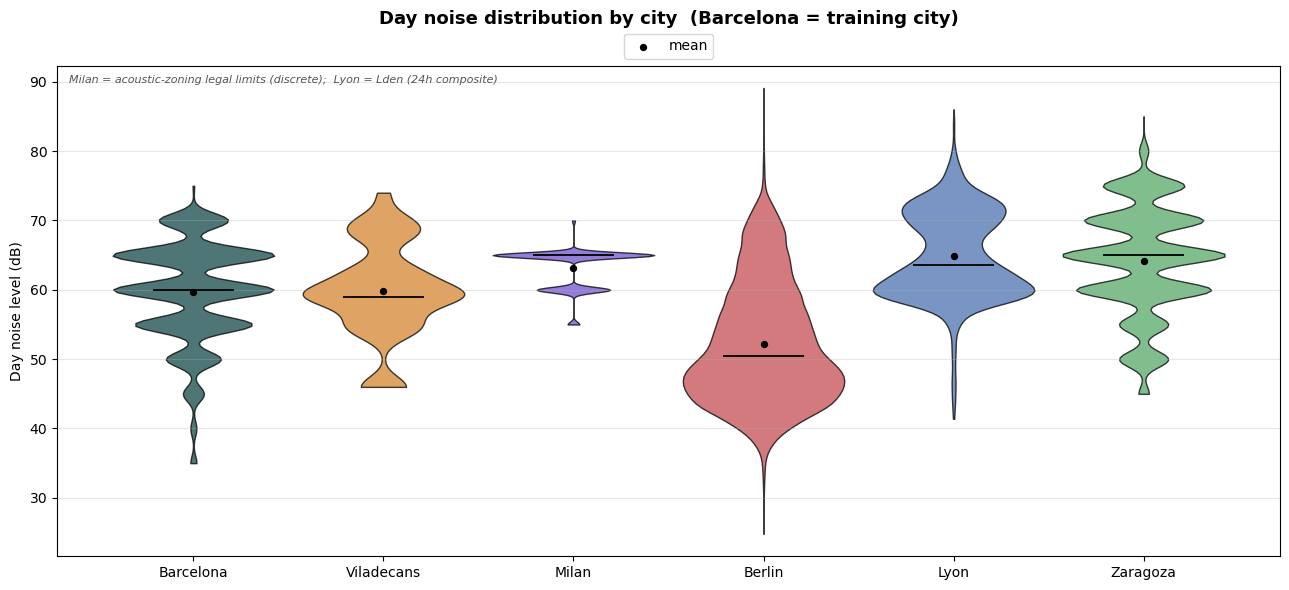

In [2]:
fig, ax = plt.subplots(figsize=(13, 6))
data_db = [regre_df[c]['noise_day'].values for c in CITIES]
parts = ax.violinplot(data_db, showmedians=True, showextrema=False, widths=0.85)
for i, body in enumerate(parts['bodies']):
    body.set_facecolor(CITY_COLORS[CITIES[i]]); body.set_alpha(0.75); body.set_edgecolor('black')
parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(1.3)

# overlay mean markers
means = [np.mean(d) for d in data_db]
ax.scatter(range(1, len(CITIES) + 1), means, color='black', s=18, zorder=3, label='mean')
ax.set_xticks(range(1, len(CITIES) + 1)); ax.set_xticklabels(CITIES)
ax.set_ylabel('Day noise level (dB)')
ax.set_title('Day noise distribution by city  (Barcelona = training city)', fontsize=13, fontweight='bold', pad=30)
ax.grid(axis='y', alpha=0.3); ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.0), frameon=True)
ax.text(0.01, 0.98, 'Milan = acoustic-zoning legal limits (discrete);  Lyon = Lden (24h composite)',
        transform=ax.transAxes, va='top', fontsize=8, style='italic', color='#555')
plt.tight_layout()
plt.savefig(f'{FIG}/fig_noise_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 2 — Noise class share per city

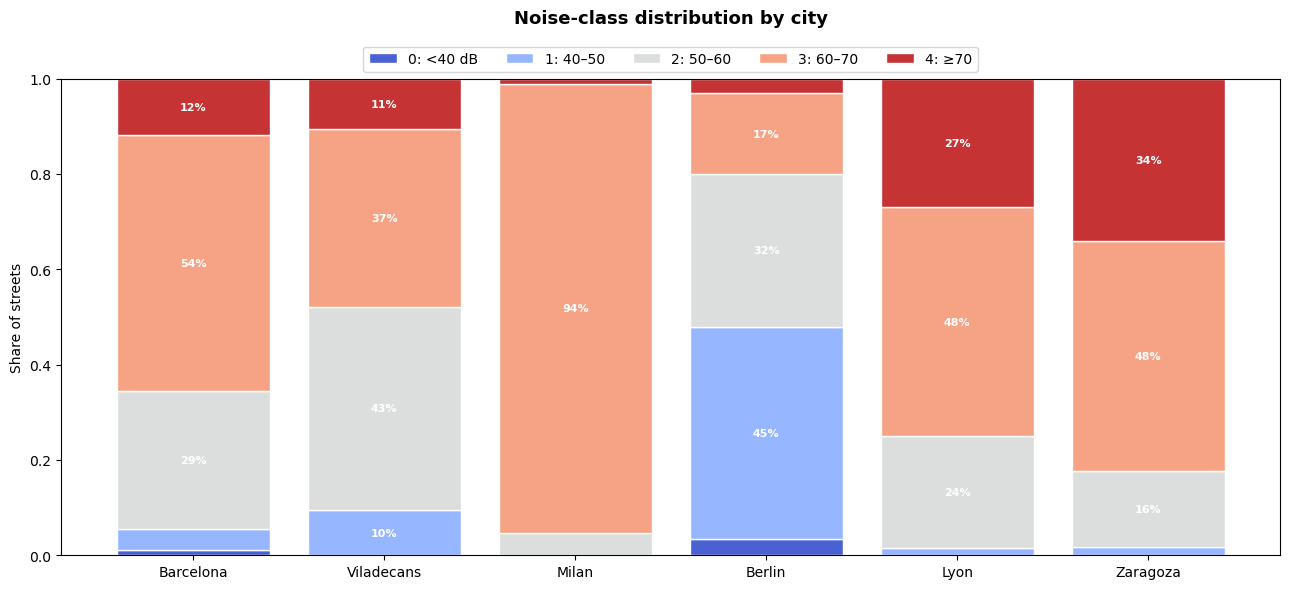

In [3]:
CLASS_LABELS = ['0: <40 dB', '1: 40–50', '2: 50–60', '3: 60–70', '4: ≥70']
class_colors = plt.cm.coolwarm(np.linspace(0.05, 0.95, 5))

shares = np.array([[class_df[c]['noise_day'].value_counts(normalize=True).get(k, 0.0)
                    for k in range(5)] for c in CITIES])

fig, ax = plt.subplots(figsize=(13, 6))
bottom = np.zeros(len(CITIES))
for k in range(5):
    bars = ax.bar(CITIES, shares[:, k], bottom=bottom, color=class_colors[k],
                  edgecolor='white', label=CLASS_LABELS[k])
    for j, v in enumerate(shares[:, k]):
        if v >= 0.06:
            ax.text(j, bottom[j] + v / 2, f'{v:.0%}', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    bottom += shares[:, k]
ax.set_ylabel('Share of streets'); ax.set_ylim(0, 1)
ax.set_title('Noise-class distribution by city', fontsize=13, fontweight='bold', pad=40)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.0), ncol=5, frameon=True)
plt.tight_layout()
plt.savefig(f'{FIG}/fig_class_share.png', dpi=150, bbox_inches='tight')
plt.show()

## Apply the Barcelona models to every city (for the results figures)

In [4]:
RAW = '../../notebooks/_elena/models'
def load(p):
    with open(p, 'rb') as f:
        return pickle.load(f)

scaler_c = load(f'{RAW}/Sscaler.pkl'); feats_c = load(f'{RAW}/feature_columns.pkl')
class_models = {'Logistic Regression': load(f'{RAW}/logreg_class_model.pkl'),
                'XGBoost': load(f'{RAW}/xgb_class_model.pkl'),
                'Random Forest': load(f'{RAW}/rf_class_model.pkl')}
scaler_r = load(f'{RAW}/Sscaler_regre.pkl'); feats_r = load(f'{RAW}/feature_columns_regre.pkl')
regre_models = {'Linear Regression': load(f'{RAW}/linreg_regre_model.pkl'),
                'XGBoost': load(f'{RAW}/xgb_regre_model.pkl'),
                'Random Forest': load(f'{RAW}/rf_regre_model.pkl')}

acc, w1, r2s, mae = {}, {}, {}, {}
for c in CITIES:
    Xc = scaler_c.transform(class_df[c][feats_c]); yc = class_df[c]['noise_day'].to_numpy()
    Xr = scaler_r.transform(regre_df[c][feats_r]); yr = regre_df[c]['noise_day'].to_numpy(dtype=float)
    if c == 'Barcelona':   # held-out 20% = source performance
        _, Xc, _, yc = train_test_split(Xc, yc, test_size=0.2, random_state=42)
        _, Xr, _, yr = train_test_split(Xr, yr, test_size=0.2, random_state=42)
    acc[c] = {m: accuracy_score(yc, mod.predict(Xc)) for m, mod in class_models.items()}
    w1[c] = {m: np.mean(np.abs(mod.predict(Xc) - yc) <= 1) for m, mod in class_models.items()}
    r2s[c] = {m: r2_score(yr, mod.predict(Xr)) for m, mod in regre_models.items()}
    mae[c] = {m: mean_absolute_error(yr, mod.predict(Xr)) for m, mod in regre_models.items()}
print('Barcelona held-out RF acc =', round(acc['Barcelona']['Random Forest'], 3),
      '| RF R2 =', round(r2s['Barcelona']['Random Forest'], 3))

Barcelona held-out RF acc = 0.749 | RF R2 = 0.704


## 3 — Transfer: classification vs Barcelona

Grouped bars per city; dashed lines = Barcelona (source) level per model. The shaded band marks the
Barcelona reference group.

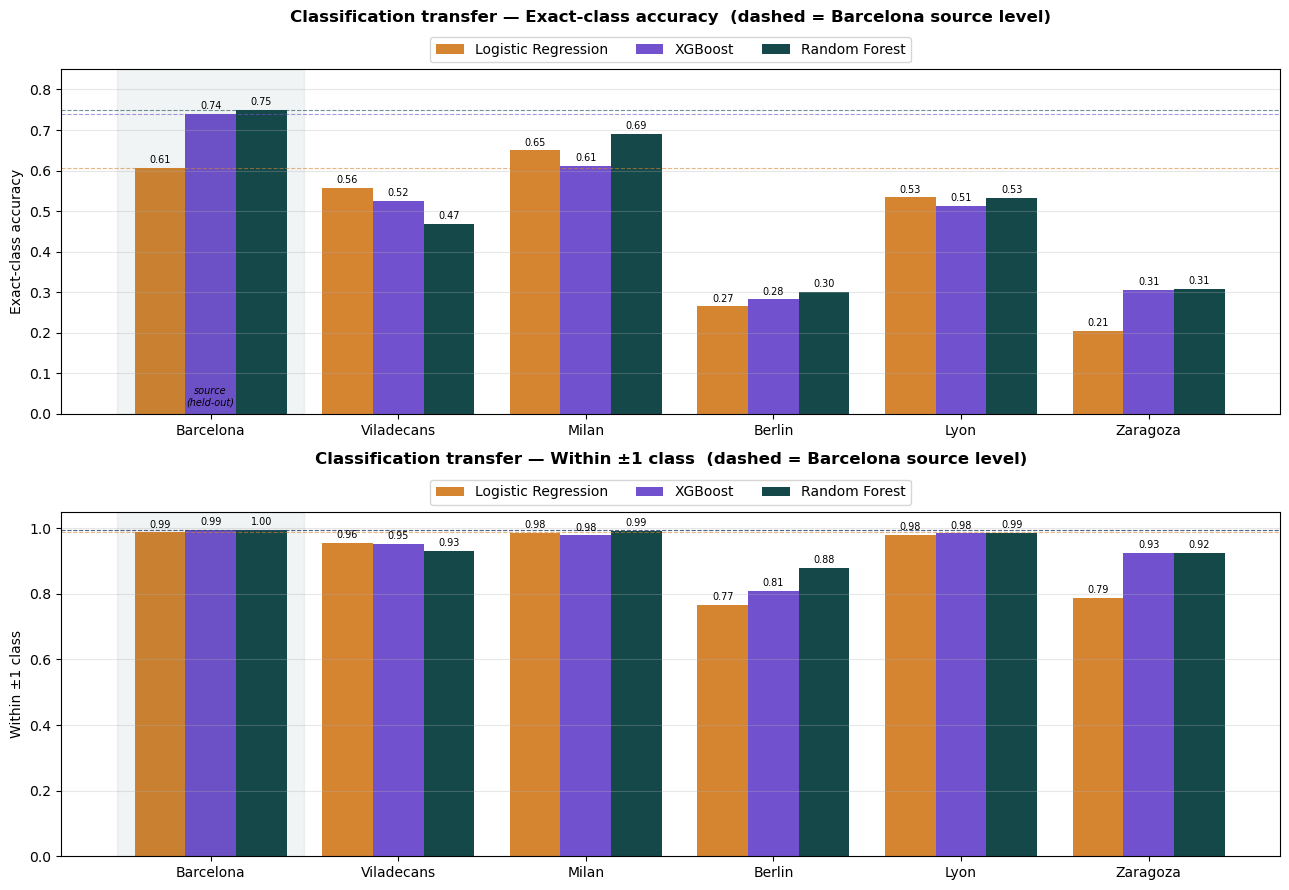

In [5]:
cmodels = ['Logistic Regression', 'XGBoost', 'Random Forest']
x = np.arange(len(CITIES)); w = 0.27

fig, axes = plt.subplots(2, 1, figsize=(13, 9))
for metric, ax, title, ylim in [(acc, axes[0], 'Exact-class accuracy', (0, 0.85)),
                                 (w1, axes[1], 'Within ±1 class', (0, 1.05))]:
    for i, m in enumerate(cmodels):
        vals = [metric[c][m] for c in CITIES]
        b = ax.bar(x + (i - 1) * w, vals, w, color=MODEL_COLORS[i], label=m)
        ax.bar_label(b, fmt='%.2f', fontsize=7, padding=2)
    for i, m in enumerate(cmodels):   # Barcelona reference lines
        ax.axhline(metric['Barcelona'][m], ls='--', lw=0.8, color=MODEL_COLORS[i], alpha=0.6)
    ax.axvspan(-0.5, 0.5, color='#144849', alpha=0.06)   # highlight Barcelona group
    ax.set_xticks(x); ax.set_xticklabels(CITIES)
    ax.set_title(f'Classification transfer — {title}  (dashed = Barcelona source level)',
                 fontsize=12, fontweight='bold', pad=34)
    ax.set_ylabel(title); ax.set_ylim(*ylim)
    ax.grid(axis='y', alpha=0.3); ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=True)
axes[0].text(0, 0.02, 'source\n(held-out)', ha='center', fontsize=7, style='italic')
plt.tight_layout()
plt.savefig(f'{FIG}/fig_transfer_classification.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 — Transfer: regression vs Barcelona

MAE in dB (lower = better) and R² (higher = better; floored at −2 for display, true value labelled).

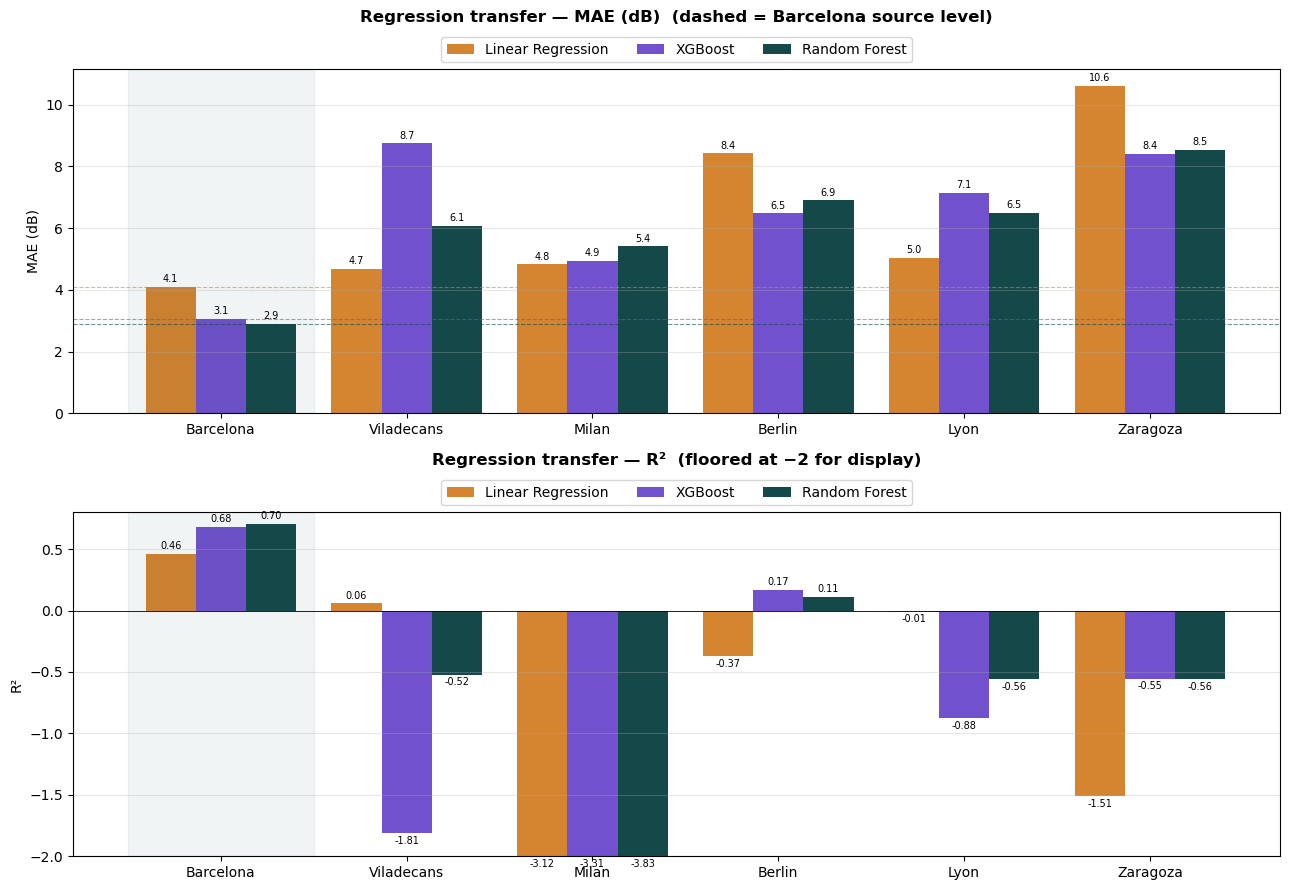

In [6]:
rmodels = ['Linear Regression', 'XGBoost', 'Random Forest']

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# MAE
for i, m in enumerate(rmodels):
    vals = [mae[c][m] for c in CITIES]
    b = axes[0].bar(x + (i - 1) * w, vals, w, color=MODEL_COLORS[i], label=m)
    axes[0].bar_label(b, fmt='%.1f', fontsize=7, padding=2)
for i, m in enumerate(rmodels):
    axes[0].axhline(mae['Barcelona'][m], ls='--', lw=0.8, color=MODEL_COLORS[i], alpha=0.6)
axes[0].axvspan(-0.5, 0.5, color='#144849', alpha=0.06)
axes[0].set_xticks(x); axes[0].set_xticklabels(CITIES)
axes[0].set_title('Regression transfer — MAE (dB)  (dashed = Barcelona source level)',
                  fontsize=12, fontweight='bold', pad=34)
axes[0].set_ylabel('MAE (dB)'); axes[0].grid(axis='y', alpha=0.3); axes[0].legend(loc='lower center', bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=True)

# R2 (floored display, true labels)
floor = -2.0
for i, m in enumerate(rmodels):
    true = [r2s[c][m] for c in CITIES]
    b = axes[1].bar(x + (i - 1) * w, [max(t, floor) for t in true], w, color=MODEL_COLORS[i], label=m)
    axes[1].bar_label(b, labels=[f'{t:.2f}' for t in true], fontsize=7, padding=2)
axes[1].axvspan(-0.5, 0.5, color='#144849', alpha=0.06)
axes[1].axhline(0, color='k', lw=0.6)
axes[1].set_xticks(x); axes[1].set_xticklabels(CITIES)
axes[1].set_title('Regression transfer — R²  (floored at −2 for display)', fontsize=12, fontweight='bold', pad=34)
axes[1].set_ylabel('R²'); axes[1].set_ylim(floor, 0.8)
axes[1].grid(axis='y', alpha=0.3); axes[1].legend(loc='lower center', bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=True)
plt.tight_layout()
plt.savefig(f'{FIG}/fig_transfer_regression.png', dpi=150, bbox_inches='tight')
plt.show()